# Exploratory Data Analysis (EDA) – Smoking & Drinking Dataset

## Objective
Explore the raw dataset to assess data quality and identify patterns relevant for predicting alcohol consumption (**DRK_YN**).

## Dataset
Smoking & Drinking Dataset (Kaggle)  
License: CC BY-NC-SA 4.0  
Source: https://www.kaggle.com/datasets/sooyoungher/smoking-drinking-dataset/data

## Output
A curated exploratory analysis that informs preprocessing decisions, feature selection, and subsequent machine learning modeling.



## Abstract

This dataset, collected from the Korean National Health Insurance Service with all personal and sensitive information removed, provides a comprehensive view of demographic, clinical, and lifestyle-related health indicators.

It includes anthropometric measurements, cardiovascular and metabolic markers, renal and liver function indicators, as well as behavioral variables such as smoking status and alcohol consumption.

In this exploratory analysis, the dataset is examined to assess data quality, identify potential data issues (such as invalid placeholder values), and explore patterns relevant for predicting alcohol consumption (`DRK_YN`). The insights obtained in this stage are used to guide preprocessing decisions and the design of subsequent machine learning models.


## Problem Definition and Analytical Context

The objective of this analysis is to explore whether demographic, behavioral, and clinical variables can provide meaningful information for predicting alcohol consumption, represented by the binary target variable `DRK_YN`.

From an analytical perspective, this exploratory stage focuses on:
- Understanding the structure and quality of the raw data.
- Identifying potential data issues, such as invalid placeholder values and extreme observations.
- Exploring relationships between alcohol consumption and key demographic, lifestyle, and clinical factors.

While the dataset also includes smoking-related variables, these are treated as explanatory features rather than prediction targets in this project.

The insights derived from this EDA are intended to inform preprocessing decisions, feature selection, and the design of subsequent machine learning models.

## Data Dictionary (selected variables)

The following table describes a subset of the most relevant variables used in this exploratory analysis.

- **sex**: biological sex (`Male`, `Female`)  
- **age**: age rounded up to the nearest 5 years  
- **height**: height rounded up to the nearest 5 cm  
- **weight**: body weight [kg]  
- **waistline**: waist circumference [cm]  
- **SBP / DBP**: systolic / diastolic blood pressure [mmHg]  
- **BLDS**: fasting blood glucose [mg/dL]  
- **tot_chole / HDL_chole / LDL_chole**: cholesterol levels [mg/dL]  
- **triglyceride**: triglycerides [mg/dL]  
- **hemoglobin**: hemoglobin [g/dL]  
- **urine_protein**: urine protein level  
  (1 = normal, higher values indicate abnormal findings)  
- **serum_creatinine**: serum creatinine [mg/dL]  
- **SGOT_AST / SGOT_ALT**: liver enzymes [IU/L]  
- **gamma_GTP**: γ-glutamyl transpeptidase [IU/L]  
- **SMK_stat_type_cd**: smoking status  
  (1 = never smoker, 2 = former smoker, 3 = current smoker)  
- **DRK_YN**: alcohol consumption indicator (`Y` = drinker, `N` = non-drinker)

## Libraries and configuration

This section imports the libraries required for exploratory data analysis and visualization.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

## Load dataset (raw data)

The raw dataset is loaded from a local path to ensure reproducibility outside Google Colab.

In [3]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data")
RAW_DIR = DATA_DIR / "raw"

raw_path = RAW_DIR / "smoking_driking_dataset_Ver01.csv"

if not raw_path.exists():
    raise FileNotFoundError(
        f"Raw dataset not found at: {raw_path}\n\n"
        "Download it from Kaggle (CC BY-NC-SA 4.0) and place it here:\n"
        "  data/raw/smoking_driking_dataset_Ver01.csv\n\n"
        "Kaggle source:\n"
        "  https://www.kaggle.com/datasets/sooyoungher/smoking-drinking-dataset/data"
    )

df = pd.read_csv(raw_path, encoding="utf-8")
df.shape


(991346, 24)

In [4]:
df.columns.tolist()

['sex',
 'age',
 'height',
 'weight',
 'waistline',
 'sight_left',
 'sight_right',
 'hear_left',
 'hear_right',
 'SBP',
 'DBP',
 'BLDS',
 'tot_chole',
 'HDL_chole',
 'LDL_chole',
 'triglyceride',
 'hemoglobin',
 'urine_protein',
 'serum_creatinine',
 'SGOT_AST',
 'SGOT_ALT',
 'gamma_GTP',
 'SMK_stat_type_cd',
 'DRK_YN']

In [5]:
# Normalize column names to avoid issues caused by leading/trailing spaces
df.columns = df.columns.str.strip()

## Dataset overview

This section provides a high-level view of the dataset structure, size, and data types.

In [6]:
# Display a sample of the dataset to inspect raw values and structure
df.head()

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N


In [7]:
# Inspect dataset structure, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 991346 entries, 0 to 991345
Data columns (total 24 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   sex               991346 non-null  object 
 1   age               991346 non-null  int64  
 2   height            991346 non-null  int64  
 3   weight            991346 non-null  int64  
 4   waistline         991346 non-null  float64
 5   sight_left        991346 non-null  float64
 6   sight_right       991346 non-null  float64
 7   hear_left         991346 non-null  float64
 8   hear_right        991346 non-null  float64
 9   SBP               991346 non-null  float64
 10  DBP               991346 non-null  float64
 11  BLDS              991346 non-null  float64
 12  tot_chole         991346 non-null  float64
 13  HDL_chole         991346 non-null  float64
 14  LDL_chole         991346 non-null  float64
 15  triglyceride      991346 non-null  float64
 16  hemoglobin        99

### Initial inspection of categorical variables and data completeness

From the first rows of the dataset (`df.head()`), it can be observed that:

- The variable **`sex`** is represented as a categorical string with values `Male` and `Female`.
- The target variable **`DRK_YN`** is encoded as a binary categorical indicator with values `Y` (drinker) and `N` (non-drinker).

This observation is consistent with the data types reported by `df.info()`, where both variables are stored as `object` types.

Additionally, the dataset contains **991,346 observations** across **24 variables**, and no standard missing values (`NaN`) are reported in any column.  
However, as observed later in the summary statistics, the absence of null values does not necessarily imply clean data, since some variables contain extreme values that are likely used as **placeholder codes** for missing or invalid measurements.

In [8]:
# Summary statistics for numerical variables to identify ranges and potential anomalies
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,991346.0,47.61,14.18,20.0,35.0,45.0,60.0,85.0
height,991346.0,162.24,9.28,130.0,155.0,160.0,170.0,190.0
weight,991346.0,63.28,12.51,25.0,55.0,60.0,70.0,140.0
waistline,991346.0,81.23,11.85,8.0,74.1,81.0,87.8,999.0
sight_left,991346.0,0.98,0.61,0.1,0.7,1.0,1.2,9.9
sight_right,991346.0,0.98,0.60,0.1,0.7,1.0,1.2,9.9
hear_left,991346.0,1.03,0.17,1.0,1.0,1.0,1.0,2.0
hear_right,991346.0,1.03,0.17,1.0,1.0,1.0,1.0,2.0
SBP,991346.0,122.43,14.54,67.0,112.0,120.0,131.0,273.0
DBP,991346.0,76.05,9.89,32.0,70.0,76.0,82.0,185.0


### Extreme values and potential outliers

The summary statistics reveal the presence of **extreme values** in several numerical variables.  
Some of these values may correspond to **true but rare observations**, while others are likely the result of **invalid entries or placeholder codes** used to represent missing or unavailable measurements.

Examples of potentially problematic values include:

- **waistline**: maximum value of 999 cm  
- **sight_left / sight_right**: maximum values of 9.9  
- **SGOT_AST**: maximum value of 9999  
- **gamma_GTP**: maximum value of 999  
- **cholesterol-related variables** (`tot_chole`, `HDL_chole`, `LDL_chole`): extremely large maximum values  
- **triglyceride**: maximum value of 9490  
- **serum_creatinine**: maximum value of 98  

These values are **not physiologically plausible** and are likely used as **placeholder codes** rather than actual clinical measurements.

At this exploratory stage, these observations are **not removed or corrected**.  
Instead, they are documented to inform the preprocessing stage, where invalid values will be handled explicitly (e.g., treated as missing values or addressed through robust preprocessing strategies).


## Data quality checks

This section focuses on basic data quality checks, including missing values and duplicate records.
It is important to note that the absence of standard missing values does not guarantee clean data,
as some variables may contain invalid placeholder values identified in previous sections.

### Missing values

In [10]:
df.isna().sum().sort_values(ascending=False)

sex                 0
age                 0
height              0
weight              0
waistline           0
sight_left          0
sight_right         0
hear_left           0
hear_right          0
SBP                 0
DBP                 0
BLDS                0
tot_chole           0
HDL_chole           0
LDL_chole           0
triglyceride        0
hemoglobin          0
urine_protein       0
serum_creatinine    0
SGOT_AST            0
SGOT_ALT            0
gamma_GTP           0
SMK_stat_type_cd    0
DRK_YN              0
dtype: int64

No standard missing values (`NaN`) are reported across the dataset, as all variables
show a full non-null count.

However, this result should be interpreted with caution. As observed in the summary
statistics, several variables contain extreme values that are not physiologically
plausible and are likely used as placeholder codes for missing or unavailable data.

### Duplicate records

Duplicate records are evaluated to identify repeated observations that may bias
statistical summaries and downstream modeling if not properly handled.

In [11]:
df.duplicated().sum()

np.int64(26)

The presence of duplicate rows indicates that some observations are repeated
within the dataset. While the proportion of duplicates may be small relative
to the dataset size, duplicated records can still introduce bias if left untreated.

At this exploratory stage, duplicates are only identified and documented.
Their removal or handling is deferred to the preprocessing stage to ensure
a consistent and reproducible data pipeline.

## Outliers and distribution analysis

This section explores the distribution of selected numerical variables and the presence
of extreme values. The goal is to visually assess potential outliers and distinguish
between plausible extreme observations and values that may correspond to invalid
placeholder codes identified earlier.

At this stage, no outlier treatment is applied. All findings are documented to inform
the preprocessing strategy implemented in subsequent stages.

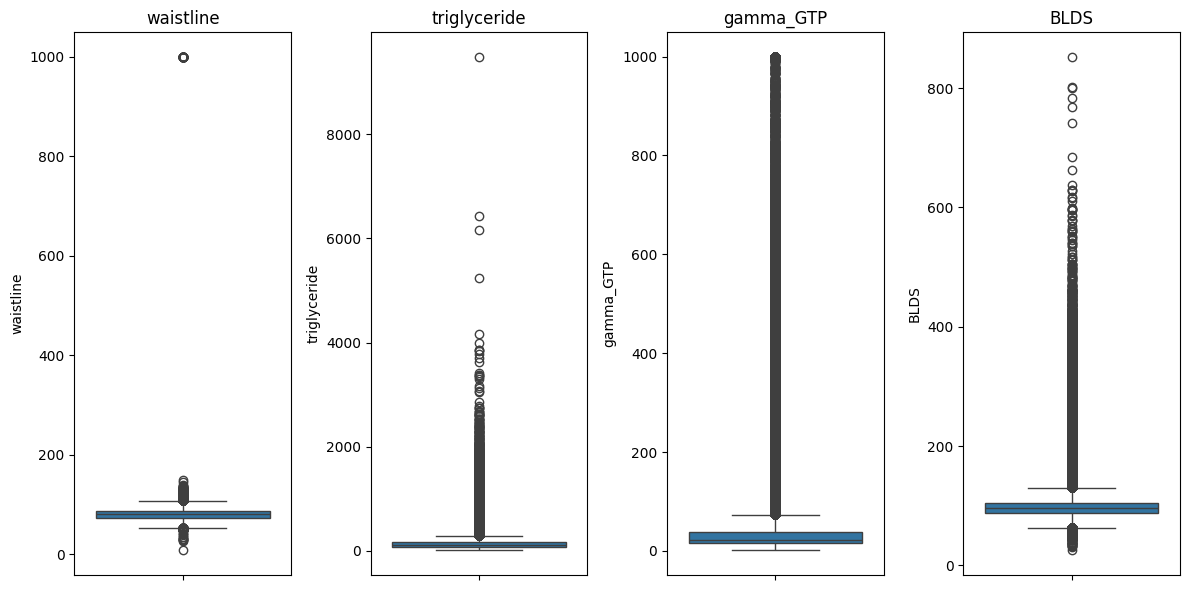

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_vars = ["waistline", "triglyceride", "gamma_GTP", "BLDS"]

plt.figure(figsize=(12, 6))

for i, col in enumerate(selected_vars, 1):
    plt.subplot(1, len(selected_vars), i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


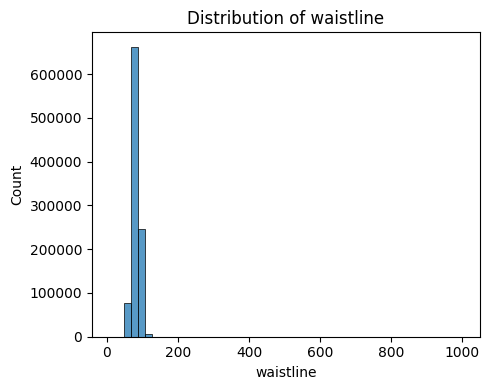

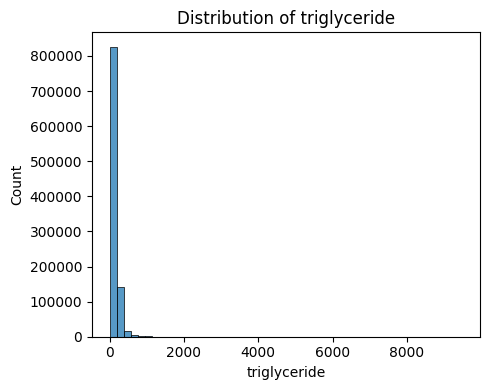

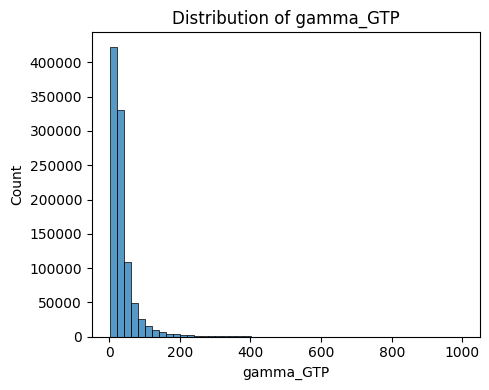

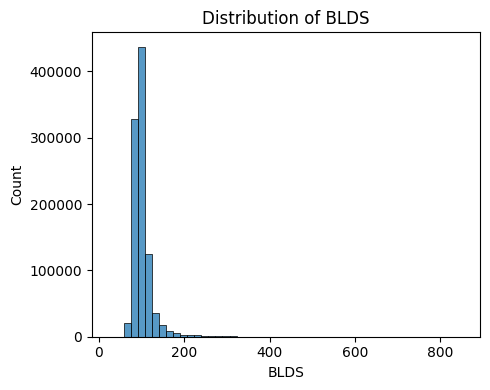

In [13]:
for col in selected_vars:
    plt.figure(figsize=(5,4))
    sns.histplot(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

### Interpretation of outliers and distributions

The boxplots reveal the presence of extreme values across several numerical variables.
In some cases, these values fall far beyond physiologically plausible ranges, strongly
suggesting the presence of invalid entries or placeholder codes rather than true
measurements.

The histograms provide additional context by showing the underlying distributional
shapes. Variables such as `gamma_GTP` and `triglyceride` exhibit right-skewed
distributions with long tails, which is consistent with known clinical behavior.
In these cases, high values may represent rare but valid observations.

In contrast, variables such as `waistline` display extreme minimum and maximum values
that are incompatible with human physiology (e.g., values close to 8 or 999),
indicating data quality issues rather than natural variability.

Across all analyzed variables, the 75th percentile lies within a relatively narrow and
plausible range, while the maximum values are orders of magnitude larger. This pattern
highlights the importance of distinguishing between naturally heavy-tailed distributions
and invalid placeholder values.

At this exploratory stage, no outliers are removed or corrected. These findings are
documented to inform preprocessing decisions, including invalid value handling,
percentile-based thresholds, robust scaling, and model selection.

### Percentile-based analysis

To further contextualize the observed extreme values, selected percentiles are
examined for key numerical variables. This analysis helps quantify how far the
extreme observations are from the bulk of the data and supports the distinction
between natural heavy-tailed behavior and invalid placeholder values.

In [15]:
selected_vars = ["waistline", "triglyceride", "gamma_GTP", "BLDS"]

df[selected_vars].quantile([0.01, 0.05, 0.75, 0.95, 0.99])

,waistline,triglyceride,gamma_GTP,BLDS
0.01,61.0,34.0,8.0,71.0
0.05,66.0,46.0,10.0,79.0
0.75,87.8,159.0,39.0,105.0
0.95,97.0,297.0,105.0,137.0
0.99,105.0,499.0,232.0,204.0


### Percentile-based analysis

The percentile analysis provides quantitative support for the visual observations.
Across all analyzed variables, the majority of observations are concentrated within
narrow and physiologically plausible ranges, while extreme values lie far beyond the
upper percentiles.

For example:

- **waistline** shows a 75th percentile of 87.8 cm and a 99th percentile of 105 cm,
  whereas the maximum recorded value reaches 999 cm. This large gap indicates that
  the extreme maximum is not a continuation of the observed distribution and is
  likely an invalid placeholder value.

- **triglyceride** values increase gradually from a 75th percentile of 159 mg/dL
  to a 99th percentile of 499 mg/dL, which may still reflect rare but plausible
  clinical cases. However, the maximum value of 9490 mg/dL lies far beyond this range,
  suggesting the presence of erroneous or placeholder entries.

- **gamma_GTP** exhibits a strongly right-skewed distribution, with a 75th percentile
  of 39 IU/L and a 99th percentile of 232 IU/L. While elevated values are expected for
  this biomarker, the maximum value of 999 IU/L is disproportionately large compared
  to the upper percentiles and is likely non-physiological.

- **BLDS** presents a 75th percentile of 105 mg/dL and a 99th percentile of 204 mg/dL,
  consistent with increasing glycemic levels. Nevertheless, the maximum value of
  852 mg/dL is far removed from these percentiles, indicating potential data quality
  issues.

Overall, the fact that the 75th percentile remains relatively low for all variables,
while the maximum values are orders of magnitude larger, strongly suggests that the
extreme observations do not represent a smooth continuation of the underlying
distributions. Instead, they are likely driven by invalid placeholder codes or data
entry errors.

These findings reinforce the conclusions drawn from the visual analysis and motivate
the use of percentile-based thresholds and robust preprocessing strategies in the
subsequent stages of the pipeline.

## Target variable analysis (DRK_YN)

This section focuses on the analysis of the target variable `DRK_YN`, which represents
alcohol consumption status. Understanding the distribution of the target variable and
its relationship with selected clinical features is essential to assess the feasibility
of the classification task and to inform downstream modeling decisions.

In [16]:
df["DRK_YN"].value_counts()

DRK_YN
N    495858
Y    495488
Name: count, dtype: int64

In [17]:
df["DRK_YN"].value_counts(normalize=True) * 100

DRK_YN
N    50.018661
Y    49.981339
Name: proportion, dtype: float64

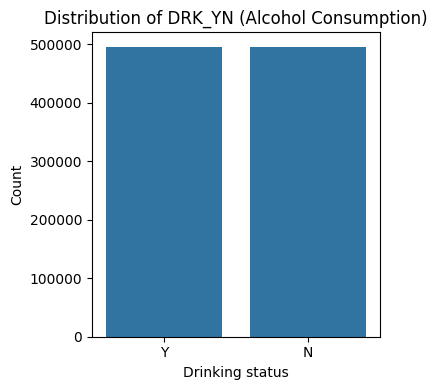

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 4))
sns.countplot(x="DRK_YN", data=df)
plt.title("Distribution of DRK_YN (Alcohol Consumption)")
plt.xlabel("Drinking status")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The target variable is almost perfectly balanced, with approximately 50% of the
observations corresponding to drinkers (`Y`) and 50% to non-drinkers (`N`).

This balanced class distribution is advantageous for modeling, as it reduces the
risk of bias toward a dominant class and allows standard evaluation metrics such as
accuracy to remain informative. Nevertheless, complementary metrics such as precision,
recall, F1-score, and ROC-AUC are still considered to provide a comprehensive
assessment of model performance.


### Relationship with a key clinical variable

In [20]:
df.groupby("DRK_YN")["gamma_GTP"].median()

DRK_YN
N    19.0
Y    29.0
Name: gamma_GTP, dtype: float64

In [21]:
df.groupby("DRK_YN")["gamma_GTP"].describe()[["50%", "75%"]]

,50%,75%
DRK_YN,,
N,19.0,29.0
Y,29.0,52.0


Median and upper-percentile values of `gamma_GTP` are higher among drinkers compared
to non-drinkers.

#### Visualization

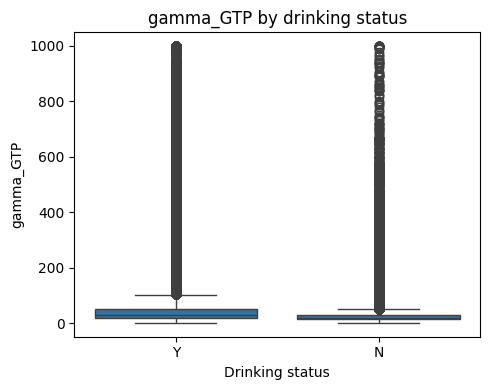

In [19]:
plt.figure(figsize=(5, 4))
sns.boxplot(x="DRK_YN", y="gamma_GTP", data=df)
plt.title("gamma_GTP by drinking status")
plt.xlabel("Drinking status")
plt.ylabel("gamma_GTP")
plt.tight_layout()
plt.show()

The distribution of `gamma_GTP` differs between drinkers and non-drinkers. Individuals
classified as drinkers (`Y`) tend to exhibit higher values and greater variability,
which is consistent with the known physiological relationship between alcohol
consumption and elevated liver enzyme levels.

Although substantial overlap between the two groups is observed, the shift in the
distribution supports the relevance of `gamma_GTP` as an informative feature for
predicting drinking behavior.

While formal correlation measures are not emphasized due to the binary nature of the
target and the skewed distributions of clinical variables, exploratory visual analysis
and domain knowledge provide sufficient evidence of feature relevance.


Overall, the balanced nature of the target variable and its meaningful association
with relevant clinical features indicate that the dataset is well suited for a
binary classification task. These findings support the development of predictive
models to infer alcohol consumption status based on the available health indicators.

## EDA summary and next steps

### Key insights

- The target variable (`DRK_YN`) is binary and almost perfectly balanced, which is
  advantageous for binary classification and simplifies model evaluation.
- Several clinical variables, including waist circumference, triglycerides, and
  liver-related enzymes, exhibit distinct distributional patterns and extreme values,
  some of which are physiologically implausible and likely correspond to invalid
  placeholder codes.
- Percentile-based analysis confirmed that the bulk of the data lies within plausible
  ranges, while maximum values are far removed from upper percentiles, highlighting
  data quality challenges.
- Visual and domain-informed analysis showed a meaningful association between alcohol
  consumption and biomarkers such as `gamma_GTP`, supporting the relevance of these
  features for predictive modeling.

### Implications for modeling

- Implement a dedicated preprocessing pipeline to identify and handle invalid
  placeholder values and extreme observations.
- Apply appropriate feature scaling and transformations to account for skewed and
  heavy-tailed distributions.
- Encode categorical variables and prepare the dataset using reproducible pipelines.
- Train and evaluate classification models using standard metrics for balanced
  datasets, including accuracy, precision, recall, F1-score, and ROC-AUC.